In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import learning_curve
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline



In [ ]:
training_data=pd.read_csv("/content/drive/MyDrive/MSc Project/trainingdata.csv")
training_data.head()


,Name,Month,Year,Max temp,Avrg temp,Min temp,Population,Age 0 to 4,Age 5 to 9,Age 10 to 14,...,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget,Percentage in 4 hours or less (type 1)
0,Barts Health NHS Trust,4,2012,12,7,3,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.940636
1,Barts Health NHS Trust,5,2012,16,12,8,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.934709
2,Barts Health NHS Trust,6,2012,17,14,10,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.936551
3,Barts Health NHS Trust,7,2012,20,16,12,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.960964
4,Barts Health NHS Trust,8,2012,22,17,13,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.939310


In [ ]:
missing_values=training_data.isna().sum()
# Filter columns with missing values
missing_values = missing_values[missing_values > 0]

# Print the columns with missing values and the number of missing values
print("Columns with missing values:")
print(missing_values)

Columns with missing values:
Series([], dtype: int64)


In [ ]:
training_data.dropna()


,Name,Month,Year,Max temp,Avrg temp,Min temp,Population,Age 0 to 4,Age 5 to 9,Age 10 to 14,...,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget,Percentage in 4 hours or less (type 1)
0,Barts Health NHS Trust,4,2012,12,7,3,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.940636
1,Barts Health NHS Trust,5,2012,16,12,8,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.934709
2,Barts Health NHS Trust,6,2012,17,14,10,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.936551
3,Barts Health NHS Trust,7,2012,20,16,12,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.960964
4,Barts Health NHS Trust,8,2012,22,17,13,2583775,153574,154251,155414,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.939310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,Wye Valley NHS Trust,8,2023,20,16,11,188522,8464,9576,10185,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.555865
908,Wye Valley NHS Trust,9,2023,20,16,12,188522,8464,9576,10185,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.539585
909,Wye Valley NHS Trust,10,2023,15,12,9,188522,8464,9576,10185,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.568541
910,Wye Valley NHS Trust,11,2023,10,7,5,188522,8464,9576,10185,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.559175


In [ ]:
encoder=OneHotEncoder(sparse_output=False)
X=training_data.iloc[:,:-1]
Y=training_data.iloc[:,-1]
Xnew=encoder.fit_transform(X[['Name']])
Xnew=pd.DataFrame(Xnew)
X=pd.DataFrame(X)
X=X.drop(columns=['Name'])
SC=StandardScaler()
X1=SC.fit_transform(X)
X1=pd.DataFrame(X1,columns=X.columns)
X=pd.concat([Xnew,X1], axis=1)
X.head()


,0,1,2,3,4,5,Month,Year,Max temp,Avrg temp,...,Age 50 to 54,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget
0,0.0,1.0,0.0,0.0,0.0,0.0,-0.746141,-1.364009,-0.223456,-0.623214,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
1,0.0,1.0,0.0,0.0,0.0,0.0,-0.457924,-1.364009,0.547023,0.469387,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
2,0.0,1.0,0.0,0.0,0.0,0.0,-0.169707,-1.364009,0.739643,0.906428,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
3,0.0,1.0,0.0,0.0,0.0,0.0,0.118510,-1.364009,1.317503,1.343469,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
4,0.0,1.0,0.0,0.0,0.0,0.0,0.406728,-1.364009,1.702742,1.561989,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447


In [ ]:
X1=X
X=X.values
Y=Y.values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42) #splitting dataset into 70% for training and 30% for testing

#Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestRegressor
modelRFR = RandomForestRegressor(n_estimators=80,max_depth=10,random_state=42)
modelRFR.fit(X_train, Y_train)



RandomForestRegressor(max_depth=10, n_estimators=80, random_state=42)

In [ ]:
PredictionRFR=modelRFR.predict(X_test)
rmseRFR = mean_squared_error(Y_test, PredictionRFR, squared=True)
r2RFR = r2_score(Y_test, PredictionRFR)

In [ ]:
print(f"Root Mean Squared Error by Random Forest Regressor Before Feature Selection: {rmseRFR}")
print(f"R Squared by Random Forest Regressor Before Feature Selection: {r2RFR}")

Root Mean Squared Error by Random Forest Regressor Before Feature Selection: 0.0011074187208469162
R Squared by Random Forest Regressor Before Feature Selection: 0.9237558558921154


In [ ]:
print(f"Root Mean Squared Error by Random Forest Regressor After Feature Selection: {rmseRFR}")
print(f"R Squared by Random Forest Regressor After Feature Selection: {r2RFR}")

Root Mean Squared Error by Random Forest Regressor After Feature Selection: 0.0011074187208469162
R Squared by Random Forest Regressor After Feature Selection: 0.9237558558921154


#XGBoost Regressor

In [ ]:
import xgboost as xgb
modelxgb= xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.01, max_depth=10, random_state=42)
modelxgb.fit(X_train, Y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
Predictionxgb=modelxgb.predict(X_test)
rmsexgb= mean_squared_error(Y_test, Predictionxgb, squared=True)
r2xgb = r2_score(Y_test, Predictionxgb)
print(f"Root Mean Squared Error by XGBoost Regressor: {rmsexgb}")
print(f"R Squared by XGBoost Regressor: {r2xgb}")

Root Mean Squared Error by XGBoost Regressor: 0.003294260683291048
R Squared by XGBoost Regressor: 0.7731950150944745


#Support Vector Regressor

In [ ]:
from sklearn.svm import SVR
# Create and train the SVR model
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train, Y_train)

SVR(C=100, gamma=0.1)

In [ ]:
Predictionsvr=svr_model.predict(X_test)
rmsesvr= mean_squared_error(Y_test, Predictionsvr, squared=True)
r2svr = r2_score(Y_test, Predictionsvr)
print(f"Root Mean Squared Error by XGBoost Regressor: {rmsesvr}")
print(f"R Squared by XGBoost Regressor: {r2svr}")

Root Mean Squared Error by XGBoost Regressor: 0.003446064980831308
R Squared by XGBoost Regressor: 0.7627435133093103


#Kfold Cross Validation of Random Forest Regressor

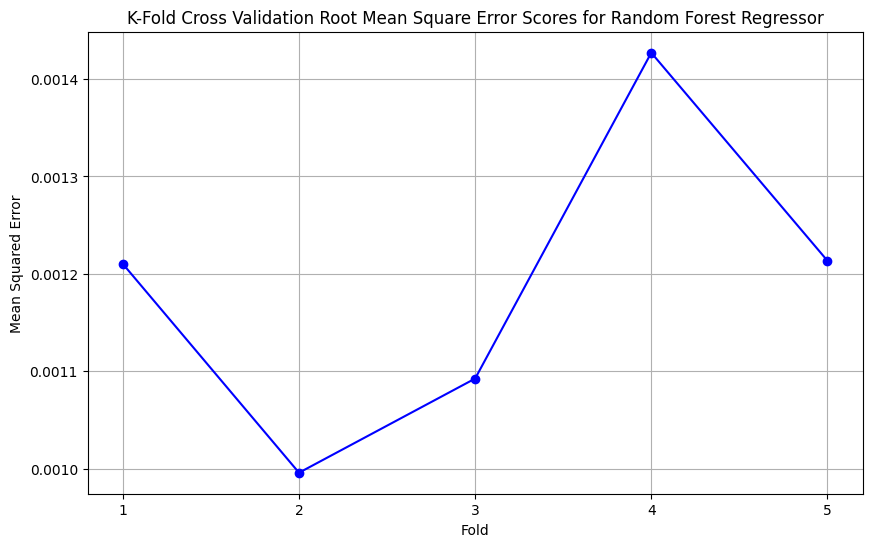

Root Mean Squared Error for Each Fold:
Fold 1: 0.0012101419318359128
Fold 2: 0.0009958668506082258
Fold 3: 0.001092523147038587
Fold 4: 0.0014269555871636982
Fold 5: 0.0012134713561582657
Average Root Mean Squared Error: 0.001187791774560938


In [ ]:
# Initialize K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Lists to hold results
mse_scores = []

# Perform K-Fold Cross Validation
for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    Y_train, Y_test = Y[train_index], Y[test_index]

    modelRFR .fit(X_train, Y_train)
    Y_pred = modelRFR .predict(X_test)

    mse = mean_squared_error(Y_test, Y_pred)
    mse_scores.append(mse)

# Plot the Mean Squared Error for each fold
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(mse_scores) + 1), mse_scores, marker='o', linestyle='-', color='b')
plt.title('K-Fold Cross Validation Root Mean Square Error Scores for Random Forest Regressor')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error')
plt.xticks(range(1, len(mse_scores) + 1))
plt.grid(True)
plt.show()

# Print the average MSE
average_mse = np.mean(mse_scores)
# Print each MSE value on a new line
print("Root Mean Squared Error for Each Fold:")
for i, mse in enumerate(mse_scores, start=1):
    print(f"Fold {i}: {mse}")
print(f"Average Root Mean Squared Error: {average_mse}")

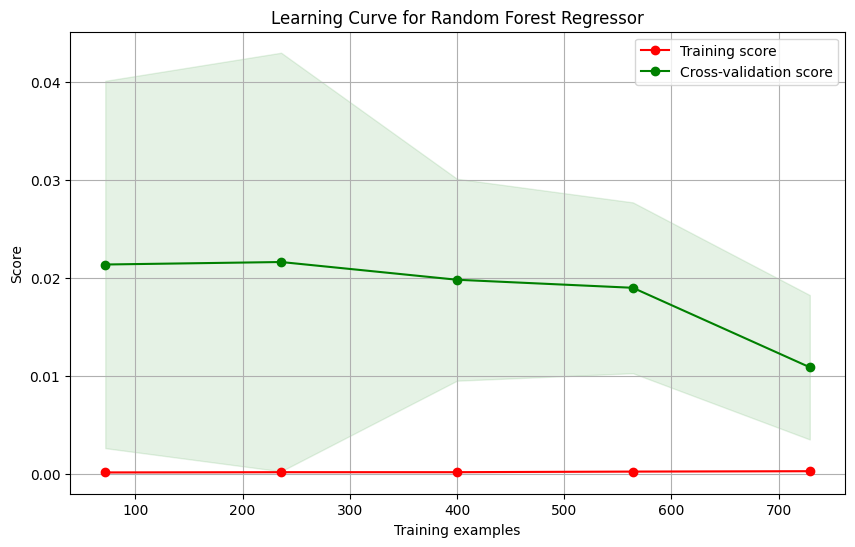

In [ ]:
import matplotlib.pyplot as plt
# Compute the learning curve
train_sizes, train_scores, test_scores = learning_curve(modelRFR, X, Y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

# Calculate the mean and standard deviation of the scores
train_scores_mean = -np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = -np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# Plot the learning curve
plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

plt.title("Learning Curve for Random Forest Regressor")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid()
plt.show()

In [ ]:
testdata=pd.read_csv("/content/drive/MyDrive/MSc Project/testingdata.csv")
testing=testdata.iloc[:,:-1]
testingnew=encoder.fit_transform(testing[['Name']])
testingnew=pd.DataFrame(testingnew)
testing=pd.DataFrame(testing)
testing=testing.drop(columns=['Name'])
testing1=SC.transform(testing)
testing1=pd.DataFrame(testing1,columns=testing.columns)
testing=pd.concat([testingnew,testing1], axis=1)
testing.head()


,0,1,2,3,4,5,Month,Year,Max temp,Avrg temp,...,Age 50 to 54,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget
0,0.0,1.0,0.0,0.0,0.0,0.0,-1.610793,1.848325,-0.993935,-0.841735,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
1,0.0,1.0,0.0,0.0,0.0,0.0,-1.322576,1.848325,-0.416076,-0.186174,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
2,0.0,1.0,0.0,0.0,0.0,0.0,-1.034358,1.848325,-0.223456,-0.186174,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
3,0.0,1.0,0.0,0.0,0.0,0.0,-0.746141,1.848325,-0.030836,0.032347,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
4,0.0,1.0,0.0,0.0,0.0,0.0,-0.457924,1.848325,0.932263,0.906428,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996


In [ ]:
importances = modelRFR.feature_importances_
feature_names = X1.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)


         feature  importance
7           Year    0.503208
31        Budget    0.148848
25  Age 65 to 69    0.084257
3              3    0.069852
30           BME    0.052727
6          Month    0.034781
8       Max temp    0.028291
10      Min temp    0.011722
9      Avrg temp    0.011572
29       Age 85+    0.003686
11    Population    0.003394
19  Age 35 to 39    0.003285
16  Age 20 to 24    0.003138
12    Age 0 to 4    0.003134
20  Age 40 to 44    0.003102
22  Age 50 to 54    0.003042
17  Age 25 to 29    0.002923
23  Age 55 to 59    0.002882
14  Age 10 to 14    0.002846
13    Age 5 to 9    0.002657
27  Age 75 to 79    0.002609
28  Age 80 to 84    0.002535
15  Age 15 to 19    0.002510
21  Age 45 to 49    0.002475
18  Age 30 to 34    0.002289
24  Age 60 to 64    0.002177
26  Age 70 to 74    0.002128
5              5    0.002105
0              0    0.000700
2              2    0.000576
1              1    0.000438
4              4    0.000113


#Data without Year and Month Column

In [ ]:
training_data=pd.read_csv("/content/drive/MyDrive/MSc Project/trainingdatanew.csv")
training_data.isna().sum()

,0
Name,0
Max temp,0
Avrg temp,0
Min temp,0
Population,0
Age 0 to 4,0
Age 5 to 9,0
Age 10 to 14,0
Age 15 to 19,0
Age 20 to 24,0


In [ ]:
training_data.dropna()

,Name,Max temp,Avrg temp,Min temp,Population,Age 0 to 4,Age 5 to 9,Age 10 to 14,Age 15 to 19,Age 20 to 24,...,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget,Percentage in 4 hours or less (type 1)
0,Barts Health NHS Trust,12,7,3,2583775,153574,154251,155414,142076,171045,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.940636
1,Barts Health NHS Trust,16,12,8,2583775,153574,154251,155414,142076,171045,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.934709
2,Barts Health NHS Trust,17,14,10,2583775,153574,154251,155414,142076,171045,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.936551
3,Barts Health NHS Trust,20,16,12,2583775,153574,154251,155414,142076,171045,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.960964
4,Barts Health NHS Trust,22,17,13,2583775,153574,154251,155414,142076,171045,...,148308,117303,88881,78030,55034,40926,39790,1291887,1060000000,0.939310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
907,Wye Valley NHS Trust,20,16,11,188522,8464,9576,10185,9162,8257,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.555865
908,Wye Valley NHS Trust,20,16,12,188522,8464,9576,10185,9162,8257,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.539585
909,Wye Valley NHS Trust,15,12,9,188522,8464,9576,10185,9162,8257,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.568541
910,Wye Valley NHS Trust,10,7,5,188522,8464,9576,10185,9162,8257,...,14723,13705,12608,13102,9765,6749,6554,5844,330000000,0.559175


In [ ]:
encoder=OneHotEncoder(sparse_output=False)
X=training_data.iloc[:,:-1]
Y=training_data.iloc[:,-1]
Xnew=encoder.fit_transform(X[['Name']])
Xnew=pd.DataFrame(Xnew)
X=pd.DataFrame(X)
X=X.drop(columns=['Name'])
SC=StandardScaler()
X1=SC.fit_transform(X)
X1=pd.DataFrame(X1,columns=X.columns)
X=pd.concat([Xnew,X1], axis=1)
X.head()


,0,1,2,3,4,5,Max temp,Avrg temp,Min temp,Population,...,Age 50 to 54,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget
0,0.0,1.0,0.0,0.0,0.0,0.0,-0.223456,-0.623214,-0.882240,2.100278,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
1,0.0,1.0,0.0,0.0,0.0,0.0,0.547023,0.469387,0.353709,2.100278,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
2,0.0,1.0,0.0,0.0,0.0,0.0,0.739643,0.906428,0.848089,2.100278,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
3,0.0,1.0,0.0,0.0,0.0,0.0,1.317503,1.343469,1.342469,2.100278,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447
4,0.0,1.0,0.0,0.0,0.0,0.0,1.702742,1.561989,1.589659,2.100278,...,2.102078,2.086351,2.068481,2.037077,1.973181,1.976002,1.992904,1.994396,2.188127,0.713447


In [ ]:
X1=X
X=X.values
Y=Y.values
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=0)


##Prediction on unseen data

In [ ]:
testdata=pd.read_csv("/content/drive/MyDrive/MSc Project/testingdatanew.csv")
testdata.head()


,Name,Max temp,Avrg temp,Min temp,Population,Age 0 to 4,Age 5 to 9,Age 10 to 14,Age 15 to 19,Age 20 to 24,...,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget,Percentage in 4 hours or less (type 1)
0,Barts Health NHS Trust,8,6,4,2909244,172920,173681,174991,159973,192591,...,166990,132079,100077,87859,61966,46082,44802,1454622,2200000000,0.865713
1,Barts Health NHS Trust,11,9,7,2909244,172920,173681,174991,159973,192591,...,166990,132079,100077,87859,61966,46082,44802,1454622,2200000000,0.847603
2,Barts Health NHS Trust,12,9,6,2909244,172920,173681,174991,159973,192591,...,166990,132079,100077,87859,61966,46082,44802,1454622,2200000000,0.930341
3,Barts Health NHS Trust,13,10,7,2909244,172920,173681,174991,159973,192591,...,166990,132079,100077,87859,61966,46082,44802,1454622,2200000000,0.854413
4,Barts Health NHS Trust,18,14,10,2909244,172920,173681,174991,159973,192591,...,166990,132079,100077,87859,61966,46082,44802,1454622,2200000000,0.870437


In [ ]:
testing=testdata.iloc[:,:-1]
testingY=testdata.iloc[:,-1]
testingnew=encoder.fit_transform(testing[['Name']])
testingnew=pd.DataFrame(testingnew)
testing=pd.DataFrame(testing)
testing=testing.drop(columns=['Name'])
testing1=SC.transform(testing)
testing1=pd.DataFrame(testing1,columns=testing.columns)
testing=pd.concat([testingnew,testing1], axis=1)
#testing=testing1
testing.head()


,0,1,2,3,4,5,Max temp,Avrg temp,Min temp,Population,...,Age 50 to 54,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget
0,0.0,1.0,0.0,0.0,0.0,0.0,-0.993935,-0.841735,-0.635051,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
1,0.0,1.0,0.0,0.0,0.0,0.0,-0.416076,-0.186174,0.106519,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
2,0.0,1.0,0.0,0.0,0.0,0.0,-0.223456,-0.186174,-0.140671,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
3,0.0,1.0,0.0,0.0,0.0,0.0,-0.030836,0.032347,0.106519,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996
4,0.0,1.0,0.0,0.0,0.0,0.0,0.932263,0.906428,0.848089,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,2.642996


In [ ]:
testing=testing.values
testingY=testingY.values

##Random Forest Regressor

In [ ]:
modelRFR = RandomForestRegressor(random_state=42)
modelRFR.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
PredictionRFR=modelRFR.predict(X_test)
rmseRFR = mean_squared_error(Y_test, PredictionRFR, squared=True)
print(f"Root Mean Squared Error by Random Forest Regressor: {rmseRFR}")

Root Mean Squared Error by Random Forest Regressor: 0.0021339351487893983


In [ ]:
PredictionRFR=modelRFR.predict(testing)
rmseRFR= mean_squared_error(testingY, PredictionRFR, squared=True)
print(f"Root Mean Squared Error by Random Forest Regressor on Unseen Data : {rmseRFR}")

Root Mean Squared Error by Random Forest Regressor on Unseen Data : 0.006062452351249277


In [ ]:
newdataRFR=pd.read_csv("/content/drive/MyDrive/MSc Project/testingdatanew.csv")
newdataRFR['Predictions RFR']=PredictionRFR
newdataRFR.head()
newdataRFR.to_csv("PredictionsRFR.csv",index=False)
result=newdataRFR.iloc[:,[0,-2,-1]]

In [ ]:
result.head(15)

,Name,Percentage in 4 hours or less (type 1),Predictions RFR
0,Barts Health NHS Trust,0.865713,0.866701
1,Barts Health NHS Trust,0.847603,0.866239
2,Barts Health NHS Trust,0.930341,0.896488
3,Barts Health NHS Trust,0.854413,0.894117
4,Barts Health NHS Trust,0.870437,0.882823
5,Northumbria Healthcare NHS Foundation Trust,0.864828,0.905809
6,Northumbria Healthcare NHS Foundation Trust,0.857844,0.919700
7,Northumbria Healthcare NHS Foundation Trust,0.840185,0.919700
8,Northumbria Healthcare NHS Foundation Trust,0.857169,0.925362
9,Northumbria Healthcare NHS Foundation Trust,0.870039,0.909182


In [ ]:
result.tail(15)

,Name,Percentage in 4 hours or less (type 1),Predictions RFR
15,Leeds Teaching Hospitals NHS Trust,0.759912,0.731384
16,Leeds Teaching Hospitals NHS Trust,0.731046,0.723454
17,Leeds Teaching Hospitals NHS Trust,0.768147,0.724975
18,Leeds Teaching Hospitals NHS Trust,0.774448,0.746588
19,Leeds Teaching Hospitals NHS Trust,0.752346,0.722365
20,East Cheshire NHS Trust,0.506900,0.569307
21,East Cheshire NHS Trust,0.491819,0.579023
22,East Cheshire NHS Trust,0.535409,0.579023
23,East Cheshire NHS Trust,0.529520,0.569414
24,East Cheshire NHS Trust,0.505572,0.579978


In [ ]:
importances = modelRFR.feature_importances_
feature_names = X1.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)


         feature  importance
29        Budget    0.351779
28           BME    0.097394
6       Max temp    0.042816
23  Age 65 to 69    0.037363
27       Age 85+    0.030514
8       Min temp    0.027456
7      Avrg temp    0.025546
20  Age 50 to 54    0.025341
21  Age 55 to 59    0.025193
26  Age 80 to 84    0.025132
25  Age 75 to 79    0.024944
19  Age 45 to 49    0.024332
12  Age 10 to 14    0.022262
9     Population    0.021590
13  Age 15 to 19    0.021243
24  Age 70 to 74    0.020361
11    Age 5 to 9    0.019948
14  Age 20 to 24    0.019908
17  Age 35 to 39    0.019722
18  Age 40 to 44    0.018585
10    Age 0 to 4    0.016357
15  Age 25 to 29    0.016149
22  Age 60 to 64    0.014354
16  Age 30 to 34    0.014223
4              4    0.013796
0              0    0.008486
2              2    0.005429
3              3    0.003831
5              5    0.003278
1              1    0.002670


In [ ]:
testing_changed=pd.read_csv("/content/drive/MyDrive/MSc Project/testingdatanew.csv")
testing_changed.head()
budgetbefore=testing_changed.iloc[:,-2]
Name=testing_changed.iloc[:,0]

In [ ]:
testing_changed.iloc[:,-2]=testing_changed.iloc[:,-2]*0.8
testing_changed.head()
budgetafter=testing_changed.iloc[:,-2]

In [ ]:
budget=pd.concat([Name,budgetbefore,budgetafter],axis=1)
budget.columns=['Name','Budget Before','Budget After']
budget.head(15)

,Name,Budget Before,Budget After
0,Barts Health NHS Trust,2200000000,1.760000e+09
1,Barts Health NHS Trust,2200000000,1.760000e+09
2,Barts Health NHS Trust,2200000000,1.760000e+09
3,Barts Health NHS Trust,2200000000,1.760000e+09
4,Barts Health NHS Trust,2200000000,1.760000e+09
5,Northumbria Healthcare NHS Foundation Trust,806090000,6.448720e+08
6,Northumbria Healthcare NHS Foundation Trust,806090000,6.448720e+08
7,Northumbria Healthcare NHS Foundation Trust,806090000,6.448720e+08
8,Northumbria Healthcare NHS Foundation Trust,806090000,6.448720e+08
9,Northumbria Healthcare NHS Foundation Trust,806090000,6.448720e+08


In [ ]:
budget.tail(15)

,Name,Budget Before,Budget After
15,Leeds Teaching Hospitals NHS Trust,2091182000,1.672946e+09
16,Leeds Teaching Hospitals NHS Trust,2091182000,1.672946e+09
17,Leeds Teaching Hospitals NHS Trust,2091182000,1.672946e+09
18,Leeds Teaching Hospitals NHS Trust,2091182000,1.672946e+09
19,Leeds Teaching Hospitals NHS Trust,2091182000,1.672946e+09
20,East Cheshire NHS Trust,209410000,1.675280e+08
21,East Cheshire NHS Trust,209410000,1.675280e+08
22,East Cheshire NHS Trust,209410000,1.675280e+08
23,East Cheshire NHS Trust,209410000,1.675280e+08
24,East Cheshire NHS Trust,209410000,1.675280e+08


In [ ]:
testing_X=testing_changed.iloc[:,:-1]
testing_Y=testing_changed.iloc[:,-1]
testingnew=encoder.fit_transform(testing_X[['Name']])
testingnew=pd.DataFrame(testingnew)
testing_X=pd.DataFrame(testing_X)
testing_X=testing_X.drop(columns=['Name'])
testing1=SC.transform(testing_X)
testing1=pd.DataFrame(testing1,columns=testing_X.columns)
testing_X=pd.concat([testingnew,testing1], axis=1)
testing_X.head()


,0,1,2,3,4,5,Max temp,Avrg temp,Min temp,Population,...,Age 50 to 54,Age 55 to 59,Age 60 to 64,Age 65 to 69,Age 70 to 74,Age 75 to 79,Age 80 to 84,Age 85+,BME,Budget
0,0.0,1.0,0.0,0.0,0.0,0.0,-0.993935,-0.841735,-0.635051,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,1.898257
1,0.0,1.0,0.0,0.0,0.0,0.0,-0.416076,-0.186174,0.106519,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,1.898257
2,0.0,1.0,0.0,0.0,0.0,0.0,-0.223456,-0.186174,-0.140671,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,1.898257
3,0.0,1.0,0.0,0.0,0.0,0.0,-0.030836,0.032347,0.106519,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,1.898257
4,0.0,1.0,0.0,0.0,0.0,0.0,0.932263,0.906428,0.848089,2.464098,...,2.469846,2.459713,2.446776,2.42212,2.364953,2.36933,2.382688,2.382292,2.525079,1.898257


In [ ]:
testing_X=testing_X.values
testing_Y=testing_Y.values
PredictionRFRnew=modelRFR.predict(testing_X)
rmseRFR= mean_squared_error(PredictionRFR, PredictionRFRnew, squared=True)
print(f"Root Mean Squared Error by Random Forest Regressor : {rmseRFR}")

Root Mean Squared Error by Random Forest Regressor : 0.006233436648045389


In [ ]:
newdataRFR=pd.read_csv("/content/PredictionsRFR.csv")
newdataRFR['Predictions RFR Budget+']=PredictionRFRnew
newdataRFR.head(15)
result=newdataRFR.iloc[:,[0,-3,-1]]
result.head(15)

,Name,Percentage in 4 hours or less (type 1),Predictions RFR Budget+
0,Barts Health NHS Trust,0.865713,0.866047
1,Barts Health NHS Trust,0.847603,0.868463
2,Barts Health NHS Trust,0.930341,0.897601
3,Barts Health NHS Trust,0.854413,0.894725
4,Barts Health NHS Trust,0.870437,0.883924
5,Northumbria Healthcare NHS Foundation Trust,0.864828,0.931732
6,Northumbria Healthcare NHS Foundation Trust,0.857844,0.941639
7,Northumbria Healthcare NHS Foundation Trust,0.840185,0.941639
8,Northumbria Healthcare NHS Foundation Trust,0.857169,0.944063
9,Northumbria Healthcare NHS Foundation Trust,0.870039,0.940438


In [ ]:
result.tail(15)

,Name,Percentage in 4 hours or less (type 1),Predictions RFR Budget+
15,Leeds Teaching Hospitals NHS Trust,0.759912,0.733419
16,Leeds Teaching Hospitals NHS Trust,0.731046,0.729777
17,Leeds Teaching Hospitals NHS Trust,0.768147,0.731738
18,Leeds Teaching Hospitals NHS Trust,0.774448,0.749949
19,Leeds Teaching Hospitals NHS Trust,0.752346,0.728768
20,East Cheshire NHS Trust,0.506900,0.707092
21,East Cheshire NHS Trust,0.491819,0.749802
22,East Cheshire NHS Trust,0.535409,0.749802
23,East Cheshire NHS Trust,0.529520,0.748562
24,East Cheshire NHS Trust,0.505572,0.812064


In [ ]:
from sklearn.inspection import permutation_importance
# Calculate permutation feature importance
perm_importance = permutation_importance(modelRFR, X_test, Y_test, n_repeats=10, random_state=42)

# Print feature importance
for i in perm_importance.importances_mean.argsort()[::-1]:
    print(f"{X1.columns[i]}: {perm_importance.importances_mean[i]:.3f} +/- {perm_importance.importances_std[i]:.3f}")

BME: 0.417 +/- 0.067
Budget: 0.334 +/- 0.028
Max temp: 0.035 +/- 0.011
Age 75 to 79: 0.010 +/- 0.004
Age 30 to 34: 0.008 +/- 0.003
Age 65 to 69: 0.007 +/- 0.003
Age 15 to 19: 0.006 +/- 0.003
Age 60 to 64: 0.005 +/- 0.003
Age 10 to 14: 0.005 +/- 0.002
Age 70 to 74: 0.005 +/- 0.003
Population: 0.004 +/- 0.002
Age 80 to 84: 0.004 +/- 0.003
Age 0 to 4: 0.004 +/- 0.002
Age 35 to 39: 0.004 +/- 0.002
Age 85+: 0.003 +/- 0.002
Age 20 to 24: 0.003 +/- 0.002
Age 50 to 54: 0.003 +/- 0.002
Age 5 to 9: 0.003 +/- 0.002
Age 45 to 49: 0.003 +/- 0.002
Age 40 to 44: 0.002 +/- 0.002
Age 25 to 29: 0.002 +/- 0.002
Age 55 to 59: 0.002 +/- 0.002
Avrg temp: -0.007 +/- 0.004
Min temp: -0.008 +/- 0.003


In [ ]:
testing=testing_X
testingY=testing_Y

##Polynomial Regressor

In [ ]:
from sklearn.linear_model import Ridge
model_ridge= Ridge(alpha=1.0)
model_ridge.fit(X_train, Y_train)


Ridge()

In [ ]:
PredictionRidge=model_ridge.predict(X_test)
rmseR = mean_squared_error(Y_test, PredictionRidge, squared=True)
print(f"Root Mean Squared Error by Ridge Regressor: {rmseR}")

Root Mean Squared Error by Ridge Regressor: 0.013253883422834581


In [ ]:
PredictionRidge=model_ridge.predict(testing)
rmseR= mean_squared_error(testingY, PredictionRidge, squared=True)
print(f"Root Mean Squared Error by Ridge Regressor : {rmseR}")

Root Mean Squared Error by Ridge Regressor : 0.0327642157648528


In [ ]:
newdataR=pd.read_csv("/content/PredictionsRFR.csv")
newdataR['Predictions Ridge']=PredictionRidge
newdataR.head()
newdataR.to_csv("PredictionsR.csv",index=False)

##Elastic Net Regressor


In [ ]:
from sklearn.linear_model import ElasticNet
modelE= ElasticNet(alpha=1.0, l1_ratio=0.5)
modelE.fit(X_train, Y_train)


ElasticNet()

In [ ]:
PredictionE=modelE.predict(X_test)
rmseE = mean_squared_error(Y_test, PredictionE, squared=True)
print(f"Root Mean Squared Error by Elastic Net Regressor: {rmseE}")

Root Mean Squared Error by Elastic Net Regressor: 0.01654232314896384


In [ ]:
PredictionE=modelE.predict(testing)
rmseR= mean_squared_error(testingY, PredictionE, squared=True)
print(f"Root Mean Squared Error by Elastic Net Regressor : {rmseE}")

Root Mean Squared Error by Elastic Net Regressor : 0.01654232314896384


In [ ]:
newdataE=pd.read_csv("/content/PredictionsR.csv")
newdataE['Predictions Elastic Net']=PredictionE
newdataE.head()
newdataE.to_csv("PredictionsE.csv",index=False)

##XGBoost Regressor


In [ ]:
import xgboost as xgb
modelxgb= xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.01, max_depth=10, random_state=42)
modelxgb.fit(X_train, Y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [ ]:
Predictionxgb=modelxgb.predict(X_test)
rmsexgb= mean_squared_error(Y_test, Predictionxgb, squared=True)
print(f"Root Mean Squared Error by XGBoost Regressor: {rmsexgb}")

Root Mean Squared Error by XGBoost Regressor: 0.004681940125349843


In [ ]:
Predictionxgb=modelxgb.predict(testing)
rmsexgb= mean_squared_error(testingY, Predictionxgb, squared=False)
print(f"Root Mean Squared Error by XGBoost Regressor : {rmsexgb}")

Root Mean Squared Error by XGBoost Regressor : 0.15340643504197907


In [ ]:
newdataxgb=pd.read_csv("/content/PredictionsE.csv")
newdataxgb['Predictions XGB']=Predictionxgb
newdataxgb.head(20)

,Name,Month,Year,Max temp,Avrg temp,Min temp,Population,Age 0 to 4,Age 5 to 9,Age 10 to 14,...,Age 80 to 84,Age 85+,BME,Budget,Percentage in 4 hours or less (type 1),Predictions,Predictions RFR,Predictions Ridge,Predictions Elastic Net,Predictions XGB
0,Barts Health NHS Trust,1,2024,8,6,4,2909244,172920,173681,174991,...,46082,44802,1454622,2200000000,0.865713,0.875413,0.684440,0.697423,0.850357,0.749823
1,Barts Health NHS Trust,2,2024,11,9,7,2909244,172920,173681,174991,...,46082,44802,1454622,2200000000,0.847603,0.883607,0.667893,0.701031,0.850357,0.749823
2,Barts Health NHS Trust,3,2024,12,9,6,2909244,172920,173681,174991,...,46082,44802,1454622,2200000000,0.930341,0.877017,0.696549,0.702985,0.850357,0.749823
3,Barts Health NHS Trust,4,2024,13,10,7,2909244,172920,173681,174991,...,46082,44802,1454622,2200000000,0.854413,0.877297,0.683186,0.704187,0.850357,0.749823
4,Barts Health NHS Trust,5,2024,18,14,10,2909244,172920,173681,174991,...,46082,44802,1454622,2200000000,0.870437,0.886535,0.684667,0.710952,0.850357,0.749823
5,Northumbria Healthcare NHS Foundation Trust,1,2024,7,5,3,321600,14198,16697,17398,...,10580,9583,4984,806090000,0.864828,0.941411,0.909333,0.839415,0.850357,0.883296
6,Northumbria Healthcare NHS Foundation Trust,2,2024,9,7,5,321600,14198,16697,17398,...,10580,9583,4984,806090000,0.857844,0.945648,0.914231,0.841820,0.850357,0.890346
7,Northumbria Healthcare NHS Foundation Trust,3,2024,9,7,5,321600,14198,16697,17398,...,10580,9583,4984,806090000,0.840185,0.941971,0.914231,0.841820,0.850357,0.890346
8,Northumbria Healthcare NHS Foundation Trust,4,2024,11,8,5,321600,14198,16697,17398,...,10580,9583,4984,806090000,0.857169,0.939338,0.922685,0.844977,0.850357,0.890346
9,Northumbria Healthcare NHS Foundation Trust,5,2024,15,12,9,321600,14198,16697,17398,...,10580,9583,4984,806090000,0.870039,0.951490,0.906431,0.849787,0.850357,0.890093


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert to PyTorch tensors
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(Y_train).reshape(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(Y_test).reshape(-1, 1)

# Define the neural network
class AENet(nn.Module):
    def __init__(self, input_size):
        super(AENet, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the model
modelNN= AENet(input_size=X_train.shape[1])

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(modelNN.parameters(), lr=0.001)

# Training loop
num_epochs = 1000
batch_size = 32

for epoch in range(num_epochs):
    for i in range(0, len(X_train), batch_size):
        batch_X = X_train[i:i+batch_size]
        batch_y = y_train[i:i+batch_size]

        # Forward pass
        outputs = modelNN(batch_X)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
modelNN.eval()
with torch.no_grad():
    y_pred = modelNN(X_test)
    test_loss = criterion(y_pred, y_test)
    print(f'Test Loss: {test_loss.item():.4f}')

# Calculate R-squared
r2 = mean_squared_error(y_test, y_pred, squared=True)
print(f'R-squared: {r2:.4f}')

Epoch [100/1000], Loss: 0.0091
Epoch [200/1000], Loss: 0.0083
Epoch [300/1000], Loss: 0.0063
Epoch [400/1000], Loss: 0.0047
Epoch [500/1000], Loss: 0.0042
Epoch [600/1000], Loss: 0.0040
Epoch [700/1000], Loss: 0.0037
Epoch [800/1000], Loss: 0.0035
Epoch [900/1000], Loss: 0.0036
Epoch [1000/1000], Loss: 0.0036
Test Loss: 0.0089
R-squared: 0.0089


In [ ]:
X_test_unseen= torch.FloatTensor(testing)
y_test_unseen= torch.FloatTensor(testingY).reshape(-1, 1)

In [ ]:
predictionNN=modelNN(X_test_unseen)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (30x24 and 2x64)

In [ ]:
newdataNN=pd.read_csv("/content/Predictions.csv")
newdataNN['Predictions NN']=predictionNN
newdataNN.head(20)

NameError: name 'predictionNN' is not defined

In [ ]:
newdataE.to_csv("PredictionsXGB.csv",index=False)

#PCA

Explained variance ratio: [0.8576936  0.11815073]


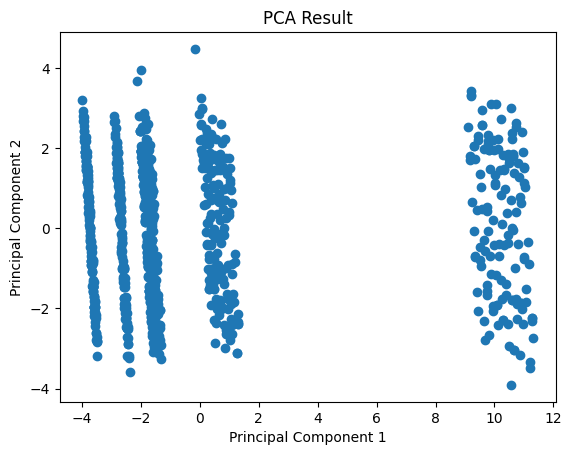

[[ 9.16239839  1.71039466]
 [ 9.29897589 -0.07291576]
 [ 9.34888284 -0.71975781]
 ...
 [-2.55823407 -1.01748415]
 [-2.69123138  0.73544869]
 [-2.6991048   0.8462522 ]]


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# Step 2: Initialize PCA and specify the number of components
pca = PCA(n_components=2)  # For example, reduce to 2 components

# Step 3: Fit and transform the data
pca_data = pca.fit_transform(X)

# Step 4: Create a DataFrame with the PCA results
pca_df = pd.DataFrame(pca_data, columns=['PC1','PC2'])

# Step 5: Examine the explained variance ratio
print(f'Explained variance ratio: {pca.explained_variance_ratio_}')

# Optional: Plot the results
plt.scatter(pca_df['PC1'], pca_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Result')
plt.show()
X=pca_data
X1=pd.DataFrame(X)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print(X)

In [ ]:
modelRFR = RandomForestRegressor(random_state=42)
modelRFR.fit(X_train, Y_train)

RandomForestRegressor(random_state=42)

In [ ]:
PredictionRFR=modelRFR.predict(X_test)
rmseRFR = mean_squared_error(Y_test, PredictionRFR, squared=True)
print(f"Root Mean Squared Error by Random Forest Regressor: {rmseRFR}")

Root Mean Squared Error by Random Forest Regressor: 0.006168076752508386


In [ ]:
testing1=pca.transform(testing)
PredictionRFR=modelRFR.predict(testing1)
rmseRFR= mean_squared_error(testingY, PredictionRFR, squared=True)
print(f"Root Mean Squared Error by Random Forest Regressor : {rmseRFR}")

Root Mean Squared Error by Random Forest Regressor : 0.004508641425779339


In [ ]:
newdataRFR=pd.read_csv("/content/Predictions.csv")
newdataRFR['Predictions RFR PCA']=PredictionRFR
newdataRFR.head()
newdataRFR.to_csv("PredictionsRFR1.csv",index=False)

In [ ]:
importances = modelRFR.feature_importances_
feature_names = X1.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df)


   feature  importance
0        0    0.670063
1        1    0.329937


In [ ]:
import plotly.express as px
import pandas as pd

# Data points for the cities
data = pd.DataFrame({
    'City': ['Barts Health NHS Trust', 'Northumbria Healthcare NHS Foundation Trust', 'Airedale NHS Foundation Trust', 'Leeds Teaching Hospitals NHS Trust', 'East Cheshire NHS Trust', 'Wye Valley NHS Trust'],
    'Latitude': [51.5074, 55.1661, 53.8008, 53.8008, 53.2326, 52.0567],
    'Longitude': [0.1278, -1.8833, -1.6491, -1.5491, -2.6148, -2.7157],
    'Average Value': [92, 91, 75, 75, 49, 53]  # Example values
})

# Define custom color scale based on specific values
# You can specify colors for specific values or ranges
custom_color_scale = [
    [0.0, 'red'],    # Color for the lowest value
    [0.5, 'yellow'], # Color for the middle value
    [1.0, 'green']   # Color for the highest value
]

# Normalize 'Average Value' to be between 0 and 1
min_value = data['Average Value'].min()
max_value = data['Average Value'].max()
data['Normalized Value'] = (data['Average Value'] - min_value) / (max_value - min_value)

# Create a scatter mapbox plot with the custom color scale
fig = px.scatter_mapbox(
    data,
    lat='Latitude',
    lon='Longitude',
    hover_name='City',
    hover_data=['Average Value'],
    color='Normalized Value',
    color_continuous_scale=custom_color_scale,
    size='Average Value',
    size_max=10,
    zoom=5,
    mapbox_style='carto-positron'
)

fig.show()

